#Based on a countries economic, demographic, and other factors, I want to predict the birth rate of a country

There are a bunch of seperate datasets from the same website that need to be combined together. First step is to import all the datasets, then figure out what to do with nulls, and finally combine everything into one dataset.

In [ ]:
import pandas as pd

In [ ]:
url1 = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRnuTleQLeCzRYiKcgOAIRIR930eMF_8irtWEJ_-2ZqN6IatLFvqt3thAcETQPFoN8hRLwCcsSdbAy4/pub?output=csv'
gdp = pd.read_csv(url1)
gdp.head()

,Country Name,Country Code,Indicator Name,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,GDP (constant LCU),5.323765e+09,5.201168e+09,3.953793e+09,5.046597e+09,5.574386e+09,NaN
1,Africa Eastern and Southern,AFE,GDP (constant LCU),NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,GDP (constant LCU),1.369527e+12,1.423097e+12,1.389639e+12,1.101444e+12,1.032712e+12,NaN
3,Africa Western and Central,AFW,GDP (constant LCU),NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,GDP (constant LCU),1.558938e+12,1.547990e+12,1.460711e+12,1.478228e+12,1.523246e+12,1.536285e+12


In [ ]:
gdp.shape

(266, 9)

In [ ]:
url2 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQs2ErHYLgFD_p2P1kgcTm0_vgxNiplJoJWCpG-01dRftMp4DT5ZyusQR8DemAcHzO4qmfmNZh-N6E6/pub?output=csv"
literacy = pd.read_csv(url2)
literacy.head()

,Country Name,Country Code,Indicator Name,Indicator Code,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,"Literacy rate, adult total (% of people ages 1...",SE.ADT.LITR.ZS,NaN,NaN,97.989998,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Literacy rate, adult total (% of people ages 1...",SE.ADT.LITR.ZS,71.392616,72.634972,72.785622,72.581161,72.600403,NaN
2,Afghanistan,AFG,"Literacy rate, adult total (% of people ages 1...",SE.ADT.LITR.ZS,NaN,NaN,NaN,37.266041,NaN,NaN
3,Africa Western and Central,AFW,"Literacy rate, adult total (% of people ages 1...",SE.ADT.LITR.ZS,59.568459,59.511719,59.617512,60.034611,60.312698,NaN
4,Angola,AGO,"Literacy rate, adult total (% of people ages 1...",SE.ADT.LITR.ZS,NaN,NaN,NaN,NaN,72.400002,NaN


In [ ]:
literacy.shape

(266, 10)

In [ ]:
url3 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vR-9X_y1grCiZzunpclhJgguGwHsAkknWNdGa9KppcnMKe4WyDDsqMyRQTWpOoGMPDRLXNSZE2POj9s/pub?output=csv"
trade = pd.read_csv(url3)
trade.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,162.882052,145.833663,142.239763,143.804295,145.213552,145.343573,124.162374,139.900087,160.459257,NaN
1,Africa Eastern and Southern,AFE,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,60.977489,55.558015,52.885423,52.547729,55.572220,52.624518,50.408052,55.737320,58.848396,56.189745
2,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,46.709895,51.411716,72.885470,NaN
3,Africa Western and Central,AFW,Trade (% of GDP),NE.TRD.GNFS.ZS,33.02326,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,79.332923,62.888516,53.370158,52.256822,66.378013,57.829538,65.942029,74.464499,69.699045,66.534149


In [ ]:
url4 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vR-9X_y1grCiZzunpclhJgguGwHsAkknWNdGa9KppcnMKe4WyDDsqMyRQTWpOoGMPDRLXNSZE2POj9s/pub?output=csv"
HCI = pd.read_csv(url4)
HCI.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,162.882052,145.833663,142.239763,143.804295,145.213552,145.343573,124.162374,139.900087,160.459257,NaN
1,Africa Eastern and Southern,AFE,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,60.977489,55.558015,52.885423,52.547729,55.572220,52.624518,50.408052,55.737320,58.848396,56.189745
2,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,46.709895,51.411716,72.885470,NaN
3,Africa Western and Central,AFW,Trade (% of GDP),NE.TRD.GNFS.ZS,33.02326,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Trade (% of GDP),NE.TRD.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,79.332923,62.888516,53.370158,52.256822,66.378013,57.829538,65.942029,74.464499,69.699045,66.534149


In [ ]:
url5 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vT6ZbGufbPh3Tgrzd8zZbLgN4AnfRO6sZWA4SDVxAYkD4ARzJxUvDCnmbaUe87jEfRi0B21-uL6xBgo/pub?output=csv"

household = pd.read_csv(url5)
household.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Households and NPISHs final consumption expend...,NE.CON.PRVT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,58.395863,55.333222,54.536356,55.134110,55.235260,53.937333,63.347346,59.072630,53.754377,NaN
1,Africa Eastern and Southern,AFE,Households and NPISHs final consumption expend...,NE.CON.PRVT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,64.569547,67.098878,67.808161,66.640286,67.407398,67.049330,66.361278,65.159518,65.887251,68.962783
2,Afghanistan,AFG,Households and NPISHs final consumption expend...,NE.CON.PRVT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,92.303347,88.478323,97.611499,NaN
3,Africa Western and Central,AFW,Households and NPISHs final consumption expend...,NE.CON.PRVT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Households and NPISHs final consumption expend...,NE.CON.PRVT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,44.466746,52.743997,56.025799,57.182498,56.361466,49.936913,54.048464,44.830754,46.883525,53.814272


In [ ]:
url6 = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vS3e9sFpJpLeZD7N1Zq-r71UELSuuyFNDDvHN6VUIBTxq-AvLOyiXGt4oPYFGTObz8mI_-FzeNcB-N_/pub?output=csv'
unemployment = pd.read_csv(url6)
unemployment

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.915000,NaN,NaN,11.184000,NaN,NaN,11.710,5.679,NaN,NaN
3,Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.356261,NaN,NaN,6.991771,NaN,7.120584,NaN,NaN,3.031437,NaN
4,Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,9.579000,NaN,NaN,NaN,NaN,16.497000,NaN,15.799,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,35.264000,32.840,27.491,30.344000,27.761,25.069000,25.459,20.392,12.093000,NaN
262,"Yemen, Rep.",YEM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,13.467000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.890000,25.149,26.537,27.035000,26.906,28.468000,29.217,34.007,33.268000,32.098
264,Zambia,ZMB,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,11.888,NaN,4.529000,5.033,5.542000,6.033,5.199,5.995000,NaN


In [ ]:
url7 = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQYrywvWhEJDe72FWNVvvI1TTCPyr8Bz-cbp8pnmuyjAwQHWChusFbYQ3GQggTGwY5bfIeAFsUWHHQB/pub?output=csv'
birth = pd.read_csv(url7)
birth.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,33.883000,32.831000,31.649000,30.416000,29.147000,27.889000,...,13.533000,12.428000,12.300000,11.530000,9.881000,9.138000,8.102000,7.193000,7.178000,NaN
1,Africa Eastern and Southern,AFE,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,47.438554,47.530552,47.597558,47.636140,47.645480,47.667660,...,36.028318,35.613314,35.189016,34.892536,34.611022,34.341450,33.916746,33.546266,33.142041,NaN
2,Afghanistan,AFG,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,50.340000,50.443000,50.570000,50.703000,50.831000,50.872000,...,39.105000,38.803000,37.936000,37.342000,36.927000,36.466000,36.051000,35.842000,35.143000,NaN
3,Africa Western and Central,AFW,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,47.325476,47.421051,47.529223,47.531029,47.511923,47.468568,...,39.335352,38.859210,38.393100,37.881661,37.447087,37.027834,36.615730,36.237034,35.776241,NaN
4,Angola,AGO,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,51.026000,51.282000,51.316000,51.323000,51.282000,51.282000,...,42.676000,42.020000,41.377000,40.810000,40.236000,39.725000,39.271000,38.809000,38.200000,NaN


In [ ]:
x = [gdp,literacy, birth, unemployment, household, HCI, trade]
for i in x:
  y = i[['Country Name','2018','2023']]
  print(y.isna().sum())
  print("----------------------------------------------------------------------")


Country Name     0
2018            56
2023            81
dtype: int64
----------------------------------------------------------------------
Country Name      0
2018            187
2023            265
dtype: int64
----------------------------------------------------------------------
Country Name      0
2018              3
2023            266
dtype: int64
----------------------------------------------------------------------
Country Name      0
2018            118
2023            174
dtype: int64
----------------------------------------------------------------------
Country Name      0
2018             45
2023            106
dtype: int64
----------------------------------------------------------------------
Country Name     0
2018            38
2023            97
dtype: int64
----------------------------------------------------------------------
Country Name     0
2018            38
2023            97
dtype: int64
----------------------------------------------------------------------


We are only going to be looking at data from the year 2018 because those have the least amount of null

In [ ]:
literacy.isna().sum()

,0
Country Name,0
Country Code,0
Indicator Name,0
Indicator Code,0
2018,187
2019,198
2020,194
2021,182
2022,179
2023,265


In [ ]:
non_na_row = literacy[literacy['2023'].notna()]
non_na_row

,Country Name,Country Code,Indicator Name,Indicator Code,2018,2019,2020,2021,2022,2023
15,Azerbaijan,AZE,"Literacy rate, adult total (% of people ages 1...",SE.ADT.LITR.ZS,NaN,99.795982,NaN,NaN,NaN,99.782562


Because literacy and unemployment have lots of null, I am going to find new datasets that don't have as many nulls. This also means that since the data is going to be from a new website, some countries aren't going to be the same. This means I have to filter in the end.

In [ ]:
lit = pd.read_csv('/content/drive/MyDrive/AI dataset GDP/Adult_Literacy_Rate_by_country (1).csv')
lit.tail()

,OBJECTID,sovereignt,type,name,name_long,abbrev,formal_en,region_wb,LITERACY_RT_TOTAL,TOTAL_YEAR,LITERACY_RT_FEMALE,FEMALE_YEAR,LITERACY_RT_MALE,MALE_YEAR,TOTAL_YEAR_LBL
235,489,Yemen,Sovereign country,Yemen,Yemen,Yem.,Republic of Yemen,Middle East & North Africa,67.648682,2013.0,51.821621,2013.0,83.470482,2013.0,(2013)
236,490,South Africa,Sovereign country,South Africa,South Africa,S.Af.,Republic of South Africa,Sub-Saharan Africa,93.729469,2012.0,92.586250,2012.0,94.963722,2012.0,(2012)
237,491,Zambia,Sovereign country,Zambia,Zambia,Zambia,Republic of Zambia,Sub-Saharan Africa,61.428288,2007.0,51.786968,2007.0,71.947433,2007.0,(2007)
238,492,Zimbabwe,Sovereign country,Zimbabwe,Zimbabwe,Zimb.,Republic of Zimbabwe,Sub-Saharan Africa,83.582718,2011.0,80.065659,2011.0,87.764809,2011.0,(2011)
239,493,Tuvalu,Sovereign country,Tuvalu,Tuvalu,Tuv.,Tuvalu,East Asia & Pacific,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
lit.isna().sum()

,0
OBJECTID,0
sovereignt,0
type,0
name,0
name_long,0
abbrev,0
formal_en,0
region_wb,0
LITERACY_RT_TOTAL,25
TOTAL_YEAR,80


In [ ]:
find = gdp.loc[gdp['Country Name'] == 'Nauru']
find

,Country Name,Country Code,Indicator Name,2018,2019,2020,2021,2022,2023
179,Nauru,NRU,GDP (constant LCU),106574257.4,115683168.3,117504950.5,126613861.4,129346534.7,130257425.7


Found new data sets for two

In [ ]:
url9 ='https://docs.google.com/spreadsheets/d/e/2PACX-1vSku0S0vy1lBuozQozg-OFZKnwY0EK0m_uT_T0uFcLSb0ZZBN_61ojl5cj3Jgv0BUewHZv_EbhFb1Nk/pub?output=csv'
literacy_new = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSku0S0vy1lBuozQozg-OFZKnwY0EK0m_uT_T0uFcLSb0ZZBN_61ojl5cj3Jgv0BUewHZv_EbhFb1Nk/pub?output=csv')
literacy_new

,Name,Lit_rate
0,Afghanistan,31.741117
1,Albania,97.246964
2,Algeria,72.648682
3,American Samoa,97.000000
4,Andorra,100.000000
...,...,...
206,Venezuela,94.770226
207,Vietnam,93.520454
208,Yemen,67.648682
209,Zambia,61.428288


In [ ]:
url10 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQl3yyf1vFNezn2h_waxUkMRNSC2j8kh6-L0ijTguV_0pBLlf9AE65st42diB3yZVKlH3zGrrRvts1p/pub?output=csv"
unemployment_new = pd.read_csv(url10)
unemployment_new

,name,slug,%,date_of_information,ranking,region
0,Afghanistan,afghanistan,14.39,2023,186,South Asia
1,Albania,albania,11.58,2023,174,Europe
2,Algeria,algeria,11.81,2023,177,Africa
3,Andorra,andorra,3.70,2016,70,Europe
4,Angola,angola,14.62,2023,187,Africa
...,...,...,...,...,...,...
204,Virgin Islands,virgin-islands,12.09,2023,179,Central America and the Caribbean
205,West Bank,west-bank,24.42,2022,204,Middle East
206,Yemen,yemen,17.22,2023,194,Middle East
207,Zambia,zambia,5.91,2023,118,Africa


In [ ]:
literacy_new.isna().sum()

,0
Country Name,0
2018,0


In [ ]:
unemployment_new.isna().sum()

,0
Country Name,0
slug,0
2018,0
date_of_information,0
ranking,0
region,0


In [ ]:
unemployment_new.rename(columns={'name': 'Country Name','%': '2018'}, inplace=True)
literacy_new.rename(columns={'Name': 'Country Name','Lit_rate': '2018'}, inplace=True)


In [ ]:
literacy_new.head()

,Country Name,2018
0,Afghanistan,31.741117
1,Albania,97.246964
2,Algeria,72.648682
3,American Samoa,97.000000
4,Andorra,100.000000


In [ ]:
x = [gdp,literacy_new, birth, unemployment_new, household, HCI, trade]
for i in x:
  y = i[['2018']]
  print(y.isna().sum())
  print("----------------------------------------------------------------------")


2018    56
dtype: int64
----------------------------------------------------------------------
2018    0
dtype: int64
----------------------------------------------------------------------
2018    3
dtype: int64
----------------------------------------------------------------------
2018    0
dtype: int64
----------------------------------------------------------------------
2018    45
dtype: int64
----------------------------------------------------------------------
2018    38
dtype: int64
----------------------------------------------------------------------
2018    38
dtype: int64
----------------------------------------------------------------------


Testing to see how to merge the datasets into one.

In [ ]:
lit_copy = literacy_new.copy()
gdp_copy = gdp.copy()
unem_copy = unemployment_new.copy()
lit_copy.rename(columns={"Name": "Country Name"}, inplace=True)
unem_copy.rename(columns={"name": "Country Name"}, inplace=True)

# Perform an inner merge on the 'country' column
combined_data = pd.merge(lit_copy, gdp_copy, on="Country Name", how="inner")
combined_data = pd.merge(combined_data, unem_copy, on="Country Name", how="inner")

# View the merged dataset
combined_data

,Country Name,2018_x,Country Code,Indicator Name,2018_y,2019,2020,2021,2022,2023,slug,2018,date_of_information,ranking,region
0,Afghanistan,31.741117,AFG,GDP (constant LCU),1.369527e+12,1.423097e+12,1.389639e+12,1.101444e+12,1.032712e+12,NaN,afghanistan,14.39,2023,186,South Asia
1,Albania,97.246964,ALB,GDP (constant LCU),1.511159e+12,1.542708e+12,1.491767e+12,1.624661e+12,1.703561e+12,1.762149e+12,albania,11.58,2023,174,Europe
2,Algeria,72.648682,DZA,GDP (constant LCU),2.288414e+13,2.309010e+13,2.193559e+13,2.276915e+13,2.358884e+13,2.455598e+13,algeria,11.81,2023,177,Africa
3,Andorra,100.000000,AND,GDP (constant LCU),2.621620e+09,2.674460e+09,2.375350e+09,2.572200e+09,2.818200e+09,2.858900e+09,andorra,3.70,2016,70,Europe
4,Angola,70.778412,AGO,GDP (constant LCU),1.558938e+12,1.547990e+12,1.460711e+12,1.478228e+12,1.523246e+12,1.536285e+12,angola,14.62,2023,187,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,Uruguay,98.363869,URY,GDP (constant LCU),1.766846e+12,1.783252e+12,1.651647e+12,1.743510e+12,1.825581e+12,1.832290e+12,uruguay,8.35,2023,150,South America
155,Uzbekistan,99.518784,UZB,GDP (constant LCU),1.308692e+14,1.386972e+14,1.414650e+14,1.519382e+14,1.605513e+14,1.701667e+14,uzbekistan,4.53,2023,87,Central Asia
156,Vanuatu,84.009468,VUT,GDP (constant LCU),6.837000e+10,7.058600e+10,6.706200e+10,6.602100e+10,6.728600e+10,6.877500e+10,vanuatu,5.10,2023,96,Australia and Oceania
157,Zambia,61.428288,ZMB,GDP (constant LCU),1.396882e+11,1.417015e+11,1.377550e+11,1.463439e+11,1.540264e+11,1.630100e+11,zambia,5.91,2023,118,Africa


In [ ]:
combined_data.isna().sum()

,0
Country Name,0
2018_x,0
Country Code,0
Indicator Name,0
2018_y,2
2019,2
2020,2
2021,2
2022,4
2023,14


In [ ]:
x = [gdp, literacy_new, birth, unemployment_new, household, HCI, trade]
names = ['gdp', 'literacy', 'birth', 'unemployment', 'household', 'HCI', 'trade']

for i in range(len(x)):
    x[i] = x[i][['Country Name', '2018']]
    x[i] = x[i].rename(columns={'2018': f'2018_{names[i]}'})
    print(x[i].head())
    print("----------------------------------------------------------------------")

                  Country Name      2018_gdp
0                        Aruba  5.323765e+09
1  Africa Eastern and Southern           NaN
2                  Afghanistan  1.369527e+12
3   Africa Western and Central           NaN
4                       Angola  1.558938e+12
----------------------------------------------------------------------
     Country Name  2018_literacy
0     Afghanistan      31.741117
1         Albania      97.246964
2         Algeria      72.648682
3  American Samoa      97.000000
4         Andorra     100.000000
----------------------------------------------------------------------
                  Country Name  2018_birth
0                        Aruba    9.881000
1  Africa Eastern and Southern   34.611022
2                  Afghanistan   36.927000
3   Africa Western and Central   37.447087
4                       Angola   40.236000
----------------------------------------------------------------------
  Country Name  2018_unemployment
0  Afghanistan             

In [ ]:
x[1].head()


,Country Name,2018_literacy
0,Afghanistan,31.741117
1,Albania,97.246964
2,Algeria,72.648682
3,American Samoa,97.000000
4,Andorra,100.000000


Combining the datasets into one

In [ ]:
x = x[2:]
data = pd.merge(gdp, literacy_new, on="Country Name", how="inner")

for df in x:
  data = pd.merge(data, df, on="Country Name", how="inner")


In [ ]:
data

,Country Name,Country Code,Indicator Name,2018_x,2019,2020,2021,2022,2023,2018_y,2018_birth,2018_unemployment,2018_household,2018_HCI,2018_trade
0,Aruba,ABW,GDP (constant LCU),5.323765e+09,5.201168e+09,3.953793e+09,5.046597e+09,5.574386e+09,NaN,96.822639,9.881,7.70,55.235260,145.213552,145.213552
1,Afghanistan,AFG,GDP (constant LCU),1.369527e+12,1.423097e+12,1.389639e+12,1.101444e+12,1.032712e+12,NaN,31.741117,36.927,14.39,NaN,NaN,NaN
2,Angola,AGO,GDP (constant LCU),1.558938e+12,1.547990e+12,1.460711e+12,1.478228e+12,1.523246e+12,1.536285e+12,70.778412,40.236,14.62,56.361466,66.378013,66.378013
3,Albania,ALB,GDP (constant LCU),1.511159e+12,1.542708e+12,1.491767e+12,1.624661e+12,1.703561e+12,1.762149e+12,97.246964,10.517,11.58,79.107713,76.808184,76.808184
4,Andorra,AND,GDP (constant LCU),2.621620e+09,2.674460e+09,2.375350e+09,2.572200e+09,2.818200e+09,2.858900e+09,100.000000,7.200,3.70,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,Samoa,WSM,GDP (constant LCU),2.097340e+09,2.190710e+09,2.122613e+09,1.972357e+09,1.867698e+09,2.016964e+09,98.973259,28.222,9.75,67.642766,78.934968,78.934968
155,Kosovo,XKX,GDP (constant LCU),5.564148e+09,5.828823e+09,5.517548e+09,6.110444e+09,6.371880e+09,6.584566e+09,91.900000,12.094,30.50,79.811036,86.315085,86.315085
156,South Africa,ZAF,GDP (constant LCU),4.571783e+12,4.583667e+12,4.310327e+12,4.513044e+12,4.599261e+12,4.626933e+12,93.729469,21.137,27.99,63.968662,54.485545,54.485545
157,Zambia,ZMB,GDP (constant LCU),1.396882e+11,1.417015e+11,1.377550e+11,1.463439e+11,1.540264e+11,1.630100e+11,61.428288,36.040,5.91,44.968083,74.888370,74.888370


In [ ]:
data = data[['Country Name','2018_x','2018_y','2018_birth','2018_unemployment','2018_household','2018_HCI','2018_trade']]

In [ ]:
data

,Country Name,2018_x,2018_y,2018_birth,2018_unemployment,2018_household,2018_HCI,2018_trade
0,Aruba,5.323765e+09,96.822639,9.881,7.70,55.235260,145.213552,145.213552
1,Afghanistan,1.369527e+12,31.741117,36.927,14.39,NaN,NaN,NaN
2,Angola,1.558938e+12,70.778412,40.236,14.62,56.361466,66.378013,66.378013
3,Albania,1.511159e+12,97.246964,10.517,11.58,79.107713,76.808184,76.808184
4,Andorra,2.621620e+09,100.000000,7.200,3.70,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
154,Samoa,2.097340e+09,98.973259,28.222,9.75,67.642766,78.934968,78.934968
155,Kosovo,5.564148e+09,91.900000,12.094,30.50,79.811036,86.315085,86.315085
156,South Africa,4.571783e+12,93.729469,21.137,27.99,63.968662,54.485545,54.485545
157,Zambia,1.396882e+11,61.428288,36.040,5.91,44.968083,74.888370,74.888370


#Final Dataset

In [ ]:
data = data.rename(columns={'2018_x': '2018_GDP', '2018_y':'2018_literacy'})
data.head()

,Country Name,2018_GDP,2018_literacy,2018_birth,2018_unemployment,2018_household,2018_HCI,2018_trade
0,Aruba,5.323765e+09,96.822639,9.881,7.70,55.235260,145.213552,145.213552
1,Afghanistan,1.369527e+12,31.741117,36.927,14.39,NaN,NaN,NaN
2,Angola,1.558938e+12,70.778412,40.236,14.62,56.361466,66.378013,66.378013
3,Albania,1.511159e+12,97.246964,10.517,11.58,79.107713,76.808184,76.808184
4,Andorra,2.621620e+09,100.000000,7.200,3.70,NaN,NaN,NaN


In [ ]:
data.isna().sum()

,0
Country Name,0
2018_GDP,2
2018_literacy,0
2018_birth,0
2018_unemployment,0
2018_household,16
2018_HCI,14
2018_trade,14


In [ ]:
null_rows = data[data.isnull().any(axis=1)]
null_rows


,Country Name,2018_GDP,2018_literacy,2018_birth,2018_unemployment,2018_household,2018_HCI,2018_trade
1,Afghanistan,1.369527e+12,31.741117,36.927,14.39,NaN,NaN,NaN
4,Andorra,2.621620e+09,100.000000,7.200,3.70,NaN,NaN,NaN
42,Eritrea,NaN,71.598099,29.105,5.87,NaN,NaN,NaN
56,Grenada,2.472980e+09,96.000000,16.920,24.00,NaN,NaN,NaN
60,Guyana,9.910440e+11,84.994011,20.770,12.43,NaN,NaN,NaN
80,Liberia,3.522161e+09,42.941086,32.706,2.94,NaN,NaN,NaN
82,Liechtenstein,NaN,100.000000,9.900,2.40,NaN,NaN,NaN
91,Maldives,8.208797e+10,98.397896,15.531,4.13,NaN,NaN,NaN
100,Malawi,6.818055e+12,61.309723,33.925,5.04,NaN,NaN,NaN
103,New Caledonia,1.007805e+12,96.671692,15.000,11.22,NaN,NaN,NaN


In [ ]:
print(null_rows.shape, data.shape)

(16, 8) (159, 8)


In [ ]:
data.loc[142, '2018_household'] = 15
data.loc[150, '2018_household'] = 67

In [ ]:
null_rows = data[data.isnull().any(axis=1)]
null_rows


,Country Name,2018_GDP,2018_literacy,2018_birth,2018_unemployment,2018_household,2018_HCI,2018_trade
1,Afghanistan,1.369527e+12,31.741117,36.927,14.39,NaN,NaN,NaN
4,Andorra,2.621620e+09,100.000000,7.200,3.70,NaN,NaN,NaN
42,Eritrea,NaN,71.598099,29.105,5.87,NaN,NaN,NaN
56,Grenada,2.472980e+09,96.000000,16.920,24.00,NaN,NaN,NaN
60,Guyana,9.910440e+11,84.994011,20.770,12.43,NaN,NaN,NaN
80,Liberia,3.522161e+09,42.941086,32.706,2.94,NaN,NaN,NaN
82,Liechtenstein,NaN,100.000000,9.900,2.40,NaN,NaN,NaN
91,Maldives,8.208797e+10,98.397896,15.531,4.13,NaN,NaN,NaN
100,Malawi,6.818055e+12,61.309723,33.925,5.04,NaN,NaN,NaN
103,New Caledonia,1.007805e+12,96.671692,15.000,11.22,NaN,NaN,NaN


In [ ]:
data.loc[142, '2018_household']

15.0

In [ ]:
data = data.dropna()

In [ ]:
data.isna().sum()

,0
Country Name,0
2018_GDP,0
2018_literacy,0
2018_birth,0
2018_unemployment,0
2018_household,0
2018_HCI,0
2018_trade,0


In [ ]:
data.shape

(145, 8)

In [ ]:
data.corr()

,2018_GDP,2018_literacy,2018_birth,2018_unemployment,2018_household,2018_HCI,2018_trade
2018_GDP,1.000000,0.030392,-0.014165,-0.046824,-0.019483,-0.086919,-0.086919
2018_literacy,0.030392,1.000000,-0.787432,-0.005837,-0.377746,0.240094,0.240094
2018_birth,-0.014165,-0.787432,1.000000,0.057661,0.402674,-0.354253,-0.354253
2018_unemployment,-0.046824,-0.005837,0.057661,1.000000,0.143744,0.030304,0.030304
2018_household,-0.019483,-0.377746,0.402674,0.143744,1.000000,-0.341942,-0.341942
2018_HCI,-0.086919,0.240094,-0.354253,0.030304,-0.341942,1.000000,1.000000
2018_trade,-0.086919,0.240094,-0.354253,0.030304,-0.341942,1.000000,1.000000


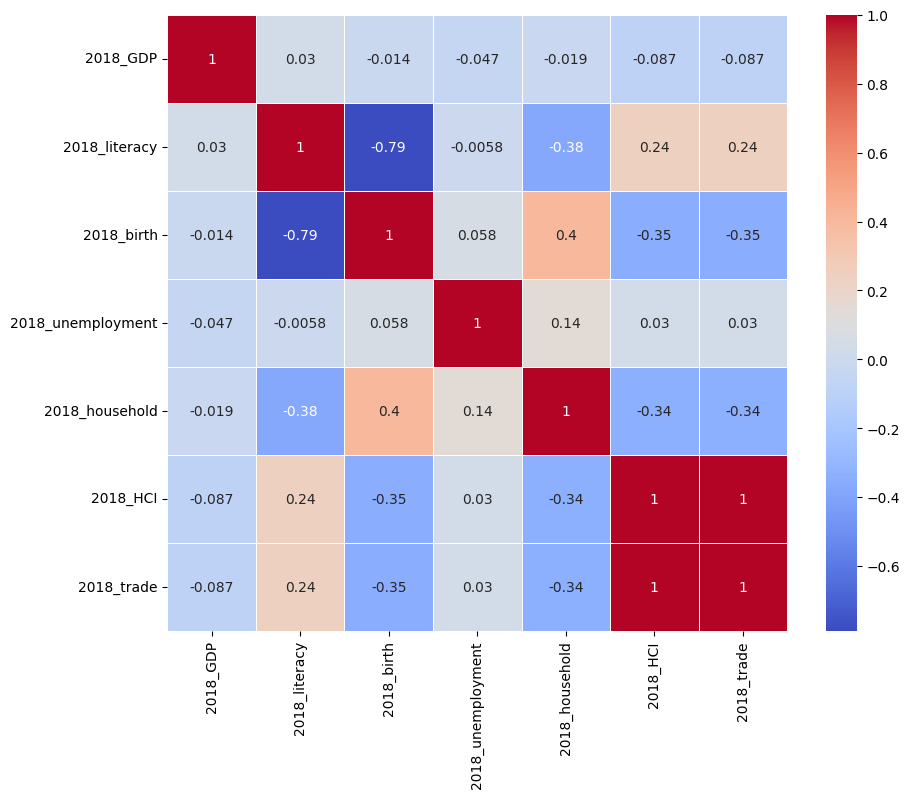

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap="coolwarm", linewidths=0.5)

plt.show()

GDP seems to have no correlation any column so its better to remove it from the dataset. HCI and trade have similar values so I am going to remove trade from the dataset. I am going to use 2018_birth as y because it has the best correlation to other columns

## Objective: To predict 2018 birth rates based on other demographics

In [ ]:
data.set_index('Country Name', inplace=True)

In [ ]:
X = data.drop(['2018_GDP', '2018_birth','2018_trade'], axis=1)
y = data["2018_birth"]

In [ ]:
y

,2018_birth
Country Name,
Aruba,9.881
Angola,40.236
Albania,10.517
United Arab Emirates,10.049
Argentina,15.187
...,...
Samoa,28.222
Kosovo,12.094
South Africa,21.137


In [ ]:
X

,2018_literacy,2018_unemployment,2018_household,2018_HCI
Country Name,,,,
Aruba,96.822639,7.70,55.235260,145.213552
Angola,70.778412,14.62,56.361466,66.378013
Albania,97.246964,11.58,79.107713,76.808184
United Arab Emirates,90.033844,2.71,37.868213,157.920573
Argentina,97.973763,6.18,69.470182,30.762536
...,...,...,...,...
Samoa,98.973259,9.75,67.642766,78.934968
Kosovo,91.900000,30.50,79.811036,86.315085
South Africa,93.729469,27.99,63.968662,54.485545


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=50)

**I tested out with different test sizes and random state. I got the best r^2 when the test_size was .15 and not .20. Probably due to not that many rows in dataset **

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train) #scaling the training set
X_test = sc.transform(X_test) #scaling the test set

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
regressor = lin_reg.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [ ]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred ))
print('R2:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 4.09214876992195
R2: 0.7788963861382919


In [ ]:
print("Predictions: ", y_pred[:5])
print("Actual values: ", y_test[:5])

Predictions:  [23.1168501  12.11000241 18.82616855 24.00701304 40.3036965 ]
Actual values:  Country Name
Lesotho         27.262
Belarus          9.900
Brazil          14.133
Guatemala       23.929
Burkina Faso    37.294
Name: 2018_birth, dtype: float64


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn_reg = KNeighborsRegressor(n_neighbors=14)
regressor = knn_reg.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [ ]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred ))
print('R2:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 4.774587662337662
R2: 0.7131313693563948


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=50, n_estimators=500)

regressor = rf_reg.fit(X_train, y_train)

y_pred = regressor.predict(X_test)


In [ ]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred ))
print('R2:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 4.792561454545457
R2: 0.692472442593161


In [ ]:
from sklearn import svm

svm_reg = svm.SVR()

regressor = svm_reg.fit(X_train, y_train)

y_pred = regressor.predict(X_test)


In [ ]:
print('Mean Absolute Error:',metrics.mean_absolute_error(y_test, y_pred ))
print('R2:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 5.716870232686949
R2: 0.5157225545756638


In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=0)

regressor = tree_reg.fit(X_train, y_train)

y_pred = tree_reg.predict(X_test)

In [ ]:
print('Mean Absolute Error:',metrics.mean_absolute_error(y_test, y_pred ))
print('R2:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 5.8465
R2: 0.5075911707423448


In [ ]:
print('R2 for each model')
print('Linear Regression:  ',0.7788963861382919 )
print('KNeighborsRegressor:  ',0.7131313693563948 )
print('RandomForestRegressor:  ', 0.692472442593161 )
print('SVM:  ', 0.5157225545756638 )

R2 for each model
Linear Regression:   0.7788963861382919
KNeighborsRegressor:   0.7131313693563948
RandomForestRegressor:   0.692472442593161
SVM:   0.5157225545756638


Linear regression worked best while svm was the worst. Initially, I wanted to predict the gdp, but after looking at the correlations, there was absolutaly no correlation between gdp and others. This led me to choose birth rate. The r2 for linear was 0.7788963861382919. It was hard to create accurate models because there arent that many countries in the world, that too with all types of records. This model could be better if there were more rows, but after looking at the correlation chart, it could be plausible countries demographic factors don't have much relation with eachother

-
-
-
-
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
- -
-
-
